# Session 11: Deep Learning for Image Processing with CNNs

**Learning goals:**

- Relate key researchers and research communities to advances in image recognition.
- Explain how local filters and shared weights make CNNs suitable for images.
- Describe convolution, stride, padding, pooling, fully connected layers and softmax.
- Compare the designs of LeNet-5, AlexNet, VGGNet and ResNet.
- Explain how depth, residual connections and GPU acceleration support image processing.
- Apply image filters, train a ResNet-18 classifier on MNIST, evaluate test predictions and measure CPU/GPU inference time.

- Explain how content and style losses update image pixels through a frozen CNN.

**Prerequisites:**

- Sessions 9–10: neural-network and deep learning fundamentals.
- Basic Python, NumPy arrays and classification concepts.
- Python with Pillow, Matplotlib, NumPy, pandas, scikit-learn, PyTorch and torchvision installed in the notebook environment.
- Run the notebook from the course folder so `assets/` and `sample_data/` paths resolve.
- The supplied `sample_data/mnist_train_small.csv` dataset and CNN images in `assets/`.
- Internet access for the first download of ResNet-18 ImageNet weights; a GPU is optional.

This notebook introduces deep learning for image processing, focusing on **Convolutional Neural Networks (CNNs)** for image classification. It uses the supplied MNIST CSV file and local diagrams.

The practical examples demonstrate image filtering and transfer learning: a frozen ImageNet backbone supplies visual features, and a new classifier learns MNIST digits. Run the training cells before evaluating predictions or comparing inference times. Training results and timings depend on your environment.


## Outline

1. Key scientists and contributors
2. Why CNNs for images?
3. CNN building blocks
4. Popular CNN architectures
5. Why networks became deeper rather than only wider
6. Image classification with CNN
7. Image style transfer


## 1 - Key Scientists and Contributors

Modern image recognition is the result of many people and many research groups. The names below are useful starting points for students because each one connects to a different part of the story.

| Scientist | Why they matter for deep learning and image recognition |
|---|---|
| [Geoffrey Hinton](https://en.wikipedia.org/wiki/Geoffrey_Hinton) | Helped revive neural networks, popularised representation learning, co-authored the AlexNet paper, and contributed to backpropagation, Boltzmann machines, and knowledge distillation. |
| [Yann LeCun](https://en.wikipedia.org/wiki/Yann_LeCun) | Developed LeNet-style CNNs for handwritten digit recognition and made convolutional networks central to computer vision. |
| [Yoshua Bengio](https://en.wikipedia.org/wiki/Yoshua_Bengio) | Helped develop deep learning theory and representation learning, especially for training deep neural networks. |
| [Fei-Fei Li](https://en.wikipedia.org/wiki/Fei-Fei_Li) | Led work on ImageNet, a large labelled image dataset that helped make large-scale visual recognition measurable and competitive. |
| [Kunihiko Fukushima](https://en.wikipedia.org/wiki/Kunihiko_Fukushima) | Proposed the Neocognitron, an early biologically inspired model with ideas similar to later convolution and pooling. |
| [Jürgen Schmidhuber](https://en.wikipedia.org/wiki/J%C3%BCrgen_Schmidhuber) | Contributed to deep learning and recurrent networks, and his group worked on early GPU-accelerated neural networks. |
| [Kaiming He](https://en.wikipedia.org/wiki/Kaiming_He) | Co-authored ResNet and He initialisation, both important for training very deep networks. |

A useful way to read this history is not as one inventor story, but as a stack of ideas: datasets, compute, architectures, optimisation methods, and open-source tools all improved together.


## 2 - Why CNNs Instead of Plain MLPs?

An image is not just a long list of pixel values. Nearby pixels usually belong together: a dog's ear, nose, outline, fur texture, and body shape are all made from local visual patterns. A plain **Multi-Layer Perceptron (MLP)** can learn from flattened pixels, but it treats each pixel position as a separate input feature. That makes the first layer large, and it does not naturally reuse the same visual detector in different parts of the image.

A CNN works differently. It first learns many small reusable filters, such as edge, outline, corner, texture, and shape detectors. These filters create **feature maps**. A smaller classifier, often an MLP-style head, then uses those feature maps to predict the class.

![CNN feature extraction from dog image](assets/cnn-dog-feature-extraction.png)

This feature-extraction approach offers three advantages:

- **fewer parameters:** a small convolutional filter is shared across the whole image instead of learning a separate weight for every pixel-location pair;
- **better accuracy and generalisation:** the network can recognise the same useful pattern even when it appears in a slightly different place;
- **more meaningful intermediate representations:** early layers can detect edges and outlines, while deeper layers combine them into parts and object-level evidence.

For example, a 28 by 28 MNIST image flattened into an MLP layer with 128 hidden units needs:

$$
784 \times 128 + 128 = 100{,}480
$$

trainable parameters in its first layer. A small convolutional layer with 8 filters of size 3 by 3 needs only:

$$
8 \times (1 \times 3 \times 3 + 1) = 80
$$

parameters. The CNN is not simply smaller; it is smaller because it uses a better assumption for images: local features are useful, and the same local feature can be reused across the image.



## 3 - CNN Building Blocks

A CNN for image classification can be understood as four main parts. The early layers extract useful visual features; the final layers turn those features into a class prediction.

| Component | Role |
|---|---|
| **Convolutional layer** | Uses learnable filters to extract local features such as edges, corners, textures, and shapes. |
| **Pooling layer** | Shrinks feature maps while keeping the strongest or average signal in each local region. |
| **Fully connected layer** | Combines extracted features to produce class scores. |
| **Softmax** | Converts class scores into probabilities that sum to 1. |


### 3.1 CNN Network Structure

The diagram below shows a typical CNN flow: image input, repeated convolution and pooling, then fully connected layers and a final prediction.

![Typical CNN architecture](assets/typical-cnn-architecture.png)

Interactive 3D demo: [Adam Harley - CNN 3D Visualisation](https://adamharley.com/nn_vis/cnn/3d.html). This visualisation shows how feature maps change as an image moves through a CNN.

Reference: inspired by [Pinecone - Visual Guide to Applied Convolution Neural Networks](https://www.pinecone.io/learn/series/image-search/cnn/). Images in this notebook are stored locally so they display offline.


### 3.2 Convolutional Layer: Filters Extract Features

A convolutional layer uses small filters to scan an image. Different filters respond to different visual patterns. For example, one filter may respond strongly to vertical edges, another to horizontal edges, and another to sharp outlines.

The animation below shows how a filter produces a feature map: the filter moves over the image, calculates one local response at a time, and builds a new representation for the next layer.

![Convolution filter producing a feature map](assets/convolution-filter-feature-map.gif)


### 3.3 Convolutional Computing

At each image position, the filter and the image patch are multiplied element by element. The products are then added together. That one number becomes one value in the output feature map.

![Convolution element-wise multiplication](assets/convolution-elementwise.png)

After this visual explanation, the next code cell applies several filters to the dog image to show how different filters highlight different features.


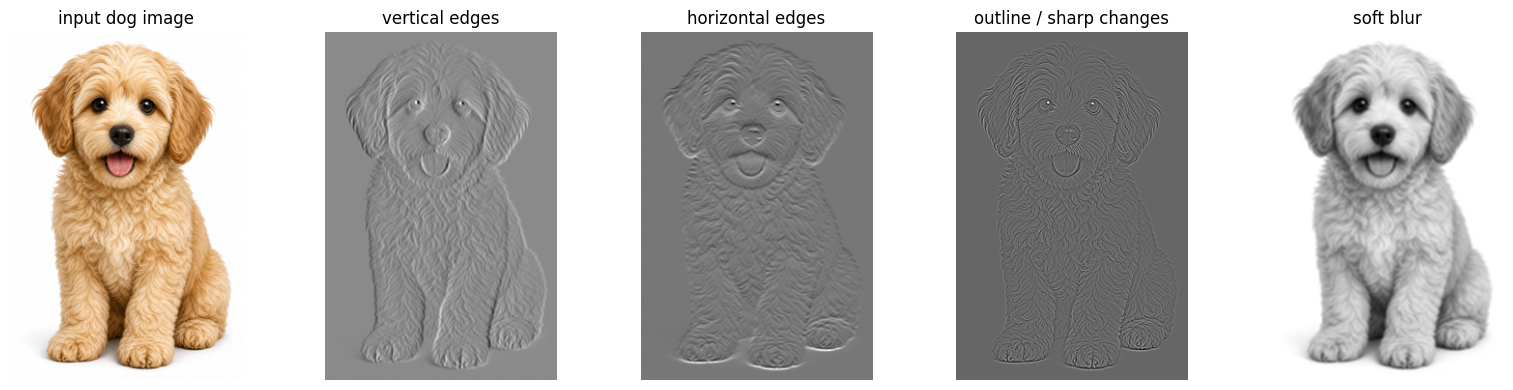

In [1]:
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np

DOG_IMAGE = "assets/dog_input.png"

# Load the image as RGB. Even though the filters below use greyscale, keeping the
# RGB version lets us display the original image beside the feature maps.
dog_rgb = Image.open(DOG_IMAGE).convert("RGB")

# Shrink the image so the nested loops below run quickly in a classroom notebook.
dog_rgb.thumbnail((360, 360))

# Convert image pixels from integers in [0, 255] to floats in [0, 1].
dog_rgb_array = np.asarray(dog_rgb, dtype=np.float32) / 255.0

# Convert RGB to greyscale using standard luminance weights.
# This gives one intensity value per pixel, which is easier for 2D filters.
dog_gray = (
    0.299 * dog_rgb_array[:, :, 0]
    + 0.587 * dog_rgb_array[:, :, 1]
    + 0.114 * dog_rgb_array[:, :, 2]
)

# Each small matrix below is a filter/kernel. Positive and negative values make
# the filter respond strongly to different patterns, such as edges or outlines.
filters = {
    "vertical edges": np.array(
        [
            [-1, 0, 1],
            [-2, 0, 2],
            [-1, 0, 1],
        ],
        dtype=np.float32,
    ),
    "horizontal edges": np.array(
        [
            [-1, -2, -1],
            [0, 0, 0],
            [1, 2, 1],
        ],
        dtype=np.float32,
    ),
    "outline / sharp changes": np.array(
        [
            [0, -1, 0],
            [-1, 4, -1],
            [0, -1, 0],
        ],
        dtype=np.float32,
    ),
    "soft blur": np.array(
        [
            [1, 1, 1],
            [1, 1, 1],
            [1, 1, 1],
        ],
        dtype=np.float32,
    ) / 9.0,
}


def apply_filter(image: np.ndarray, kernel: np.ndarray) -> np.ndarray:
    """Apply a small 2D filter using edge padding."""
    kh, kw = kernel.shape
    pad_h, pad_w = kh // 2, kw // 2

    # Padding lets the filter still be centred on border pixels.
    padded = np.pad(image, ((pad_h, pad_h), (pad_w, pad_w)), mode="edge")
    output = np.zeros_like(image, dtype=np.float32)

    # Slide the filter over every pixel location.
    for row in range(image.shape[0]):
        for col in range(image.shape[1]):
            # Extract the local image patch covered by the filter.
            patch = padded[row : row + kh, col : col + kw]

            # Element-wise multiply the patch and filter, then sum to one value.
            output[row, col] = np.sum(patch * kernel)

    return output


# Apply every filter and plot the resulting feature maps side by side.
feature_maps = {name: apply_filter(dog_gray, kernel) for name, kernel in filters.items()}

fig, axes = plt.subplots(1, 5, figsize=(16, 4))
axes[0].imshow(dog_rgb_array)
axes[0].set_title("input dog image")
axes[0].axis("off")

for ax, (name, feature_map) in zip(axes[1:], feature_maps.items()):
    ax.imshow(feature_map, cmap="gray")
    ax.set_title(name)
    ax.axis("off")

plt.tight_layout()
plt.show()  # Display the original image and the filtered feature maps.


### 3.4 Stride and Padding

**Stride** controls how far the filter moves each step. A stride of `1` checks neighbouring positions; a stride of `2` skips one position each time and produces a smaller feature map.

![Convolution stride](assets/convolution-stride.gif)

**Padding** adds extra pixels around the border before convolution. Padding helps the filter process edge pixels and can keep the output height and width closer to the input size.

![Convolution padding](assets/convolution-padding.png)


### 3.5 Pooling Layer

Pooling compresses a small region into one value. In **max pooling**, the largest value is kept. In **average pooling**, the mean value is kept.

![Average vs max pooling](assets/pooling-average-vs-max.png)

A small max-pooling example with a 2 by 2 window:

```text
Input region       Max pooling output

[1  3]
[2  4]       ->    4
```

A larger example with four non-overlapping 2 by 2 windows:

```text
Input feature map          Max-pooled feature map

[1  3  2  0]               [4  5]
[2  4  1  5]       ->      [8  7]
[0  1  7  3]
[6  8  2  4]
```


### 3.6 Fully Connected Layer and Softmax

After several convolution and pooling steps, the image has become a compact set of feature maps. These feature maps are flattened, or globally pooled, and then passed into a **fully connected classifier**.

A fully connected classifier is essentially an MLP-style classifier head: each neuron receives input from all values in the previous layer. It combines the extracted CNN features into class scores, also called **logits**.

![Fully connected layer](assets/fully-connected-layer.png)

Softmax is usually applied after the final fully connected layer for multi-class classification. It converts logits into probabilities that sum to 1, so the largest probability becomes the predicted class.

![Softmax output](assets/softmax-output.png)

A useful summary is:

```text
Convolution + pooling layers
-> extracted feature maps
-> flatten or global average pooling
-> fully connected classifier / MLP head
-> logits
-> softmax probabilities
-> predicted class
```

In PyTorch training code, the model often returns logits directly. `nn.CrossEntropyLoss()` then handles the softmax-like calculation internally, so we usually do not add an explicit `Softmax` layer before the loss.



## 4 - Popular Architectures

CNN image recognition developed rapidly after **AlexNet** won ILSVRC 2012 and greatly improved the state-of-the-art accuracy. Later architectures mainly improved depth, training stability, and computational efficiency.

![Evolution of CNN architectures](assets/cnn-architecture-evolution.png)

| Architecture | Year | Typical depth | Approx. parameters | Key contributions |
|---|---:|---:|---:|---|
| **LeNet-5** | 1998 | 7 layers | ~60 thousand | Convolution, pooling, and fully connected classification. |
| **AlexNet** | 2012 | 8 layers | ~60 million | ReLU, dropout, GPU training, and ImageNet-scale training. |
| **VGGNet** | 2014 | 16 or 19 layers | ~138-143 million | Repeated small 3 by 3 filters to build deeper CNNs. |
| **ResNet** | 2015 | 18 to 152+ layers | ~11.7-60.2 million | Residual networks for training very deep CNNs. |


### 4.1 LeNet-5

LeNet-5 is an early CNN for handwritten digit recognition. It alternates convolution and pooling, then uses fully connected layers for classification.

![LeNet-5 architecture](assets/lenet5-architecture.png)


### 4.2 AlexNet

AlexNet won ILSVRC 2012 and made large-scale CNN image classification a mainstream approach.

![AlexNet architecture](assets/alexnet-architecture.png)

Key points:

- **ReLU** uses `ReLU(x) = max(0, x)`. It is simple, fast, and keeps stronger gradients for positive values.
- **Dropout** randomly sets some activations to zero during training, reducing overfitting in fully connected layers.
- **GPU training** made the large CNN practical to train on ImageNet.

Activation functions add non-linearity so that neural networks can learn complex patterns. Earlier networks often used sigmoid or tanh, but these functions can saturate and make gradients small.

![Activation functions](assets/activation-functions.png)

The training curve below illustrates why ReLU became popular: it can reduce training error faster than tanh in deep CNNs.

![ReLU training advantage](assets/relu-training-advantage.png)


### 4.3 VGGNet

VGGNet uses a simple deep structure based on repeated **3 by 3 convolutions**.

![VGGNet architecture](assets/vggnet-architecture.png)

Key point: several small convolutions can replace one large convolution with fewer parameters and fewer multiply-add operations.

Ignoring bias terms, for a convolution with kernel size `k x k`, input channels `C_in`, output channels `C_out`, and output feature map size `H x W`:

$$
\text{parameters} = k^2 C_{in} C_{out}
$$

$$
\text{multiply-adds} \approx H W k^2 C_{in} C_{out}
$$

If `C_in = C_out = C`, one `5 x 5` convolution has:

$$
25C^2 \text{ parameters}, \quad HW \cdot 25C^2 \text{ multiply-adds}
$$

Two `3 x 3` convolutions have a similar receptive field but only:

$$
2 \times 9C^2 = 18C^2 \text{ parameters}, \quad HW \cdot 18C^2 \text{ multiply-adds}
$$

So the small-filter design reduces cost and adds an extra ReLU, giving the network more feature transformations.


### 4.4 ResNet

ResNet's key contribution is the **residual network**, which made very deep CNNs practical to train.

![ResNet architecture](assets/resnet-architecture.png)

As CNNs become deeper, gradients can become very small when they are backpropagated through many layers. This **vanishing gradient** problem makes early layers learn slowly, and adding more layers can even make training accuracy worse.

A residual block adds a shortcut connection:

$$
\mathbf{y} = F(\mathbf{x}) + \mathbf{x}
$$

The shortcut gives gradients a more direct path back through the network. Instead of learning a full mapping from scratch, the block only needs to learn the correction `F(x)`. If extra layers are not useful, the block can learn a near-zero correction and pass the input forward.

**Batch Normalisation** normalises activations during training, then learns a scale and shift. It stabilises training and helps deep networks use larger learning rates.


## 5 - Why Did Networks Become Deeper Rather Than Only Wider?

1. **From local to global image understanding**: shallow convolutional layers have small receptive fields and learn local features such as edges, corners, and textures. Deeper layers combine features from earlier layers, so the representation becomes more abstract and specific: early layers may detect animal-like patterns, later layers may recognise a dog, and still deeper layers may separate breeds such as Husky or Staffordshire Bull Terrier.

2. **Fewer weights by trading width for depth**: multiple small convolutions can replace one large convolution. For example, two `3 x 3` convolutions can cover a similar area to one `5 x 5` convolution, but use fewer weights and add more non-linear feature transformations.

3. **Trainable deep networks**: residual networks use shortcut connections to reduce vanishing-gradient problems, making much deeper CNNs practical to train.

4. **GPU acceleration**: convolution is highly parallel, so GPUs make large CNN training much faster than CPUs.


## 6 - Image Classification with CNN

This section demonstrates three practical steps:

1. load and visualise MNIST;
2. adapt a pretrained ResNet-18, train its digit classifier and evaluate held-out predictions;
3. compare CPU/GPU inference time for the trained model.


### 6.1 Load and Visualise MNIST

The first column is the digit label. The next 784 columns are the 28 by 28 greyscale pixel values.


In [2]:
# Load MNIST from CSV and name the label and pixel columns.
import pandas as pd

MNIST_CSV = "sample_data/mnist_train_small.csv"

# Each row is one image: first column = label, next 784 columns = 28 x 28 pixels.
columns = ["label"] + [f"pixel_{index}" for index in range(784)]
mnist_df = pd.read_csv(MNIST_CSV, header=None, names=columns)

# Print the dataset shape so we can confirm it loaded correctly.
print(f"Rows: {mnist_df.shape[0]:,}")
print(f"Columns: {mnist_df.shape[1]:,}")

# Display the first few rows as a table.
mnist_df.head()


Rows: 6,000
Columns: 785


,label,pixel_0,pixel_1,pixel_2,pixel_3,pixel_4,pixel_5,pixel_6,pixel_7,pixel_8,...,pixel_774,pixel_775,pixel_776,pixel_777,pixel_778,pixel_779,pixel_780,pixel_781,pixel_782,pixel_783
0,8,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


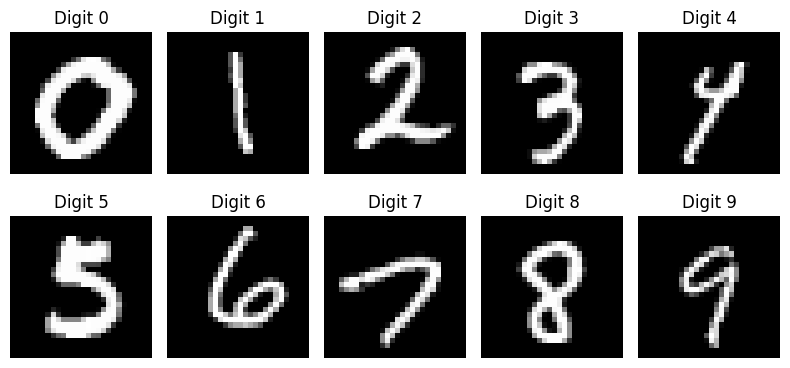

In [3]:
# Show one example image for each digit class.
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(2, 5, figsize=(8, 4))
for digit, ax in enumerate(axes.ravel()):
    # Pick the first row whose label matches the current digit.
    sample = mnist_df[mnist_df["label"] == digit].iloc[0]

    # Remove the label column and reshape 784 pixel values into a 28 x 28 image.
    image = sample.drop("label").to_numpy(dtype=np.float32).reshape(28, 28)

    ax.imshow(image, cmap="gray")
    ax.set_title(f"Digit {digit}")
    ax.axis("off")
plt.tight_layout()
plt.show()  # Display one example of each digit.


### 6.2 Adapt and Train ResNet-18

`torchvision.models` provides ResNet-18 with weights already trained on ImageNet. That training teaches the backbone to extract visual features, but its original classifier predicts 1,000 ImageNet classes. Replacing the classifier with `nn.Linear(..., 10)` creates randomly initialised weights: the new layer still needs to learn MNIST digits.

We use **transfer learning with a frozen backbone**:

1. Split MNIST into 80% training data and 20% test data, keeping similar digit proportions in each split.
2. Freeze the pretrained backbone and replace its classifier with a trainable 10-class layer.
3. Copy greyscale images into three channels, resize them and apply ImageNet normalisation.
4. Extract features once with the backbone in evaluation mode. This keeps its Batch Normalisation statistics fixed and avoids repeating convolution during every classifier-training epoch.
5. Train the new classifier for five epochs using cross-entropy loss and Adam.
6. Evaluate once on the held-out test set and inspect predictions on test images.

| Design choice | Setting |
|---|---|
| Trainable parameters | Final fully connected layer only |
| Test fraction | 20%; never used for gradient updates |
| Input size | 64 × 64 for a shorter classroom demonstration |
| Batch size | 64 |
| Optimiser | Adam, learning rate 0.001 |
| Training duration | 5 epochs |
| Evaluation | Test accuracy and a classification report |

The 64 × 64 input is a classroom adaptation; the standard pretrained ImageNet preprocessing uses a 224 × 224 crop. Accuracy depends on how well frozen ImageNet features represent digits. Full fine-tuning would also update some backbone weights. If you experiment with hyperparameters, reserve a validation set from the training data and keep the test set for the final evaluation.

[Official PyTorch transfer learning tutorial](https://docs.pytorch.org/tutorials/beginner/transfer_learning_tutorial.html) · [ResNet-18 documentation](https://docs.pytorch.org/vision/stable/models/generated/torchvision.models.resnet18.html)

In [4]:
import torch
from torch import nn
import torchvision.models as models

RANDOM_STATE = 42  # Reproduce initial weights and the later data split.
torch.manual_seed(RANDOM_STATE)

# Select an available accelerator, with CPU as the fallback.
DEVICE = "cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu"
NUM_CLASSES = 10

# DEFAULT downloads ImageNet weights on the first run and reuses them afterwards.
resnet18_weights = models.ResNet18_Weights.DEFAULT
resnet18 = models.resnet18(weights=resnet18_weights)
for parameter in resnet18.parameters():
    parameter.requires_grad = False  # Keep all existing backbone weights fixed.

# A newly created Linear layer has trainable, randomly initialised parameters.
resnet18.fc = nn.Linear(resnet18.fc.in_features, NUM_CLASSES)
resnet18 = resnet18.to(DEVICE)
resnet18.eval()  # Keep the backbone's Batch Normalisation statistics fixed.

trainable_parameters = sum(p.numel() for p in resnet18.parameters() if p.requires_grad)
print(f"Device: {DEVICE}")
print(f"Pretrained weights: {resnet18_weights}")
print(f"Trainable classifier parameters: {trainable_parameters:,}")


Device: mps
Pretrained weights: ResNet18_Weights.IMAGENET1K_V1
Trainable classifier parameters: 5,130


#### Prepare the training and test images

Split the original rows before extracting features. Both splits use the same fixed preprocessing; the test labels are used only for the final evaluation. Data loaders hold the small 28 × 28 images and resize one batch at a time to limit memory use.

In [5]:
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, TensorDataset

TEST_FRACTION = 0.2
BATCH_SIZE = 64  # Process up to 64 images in each feature-extraction batch.
INPUT_IMAGE_SIZE = 64

# Scale pixels to [0, 1] and preserve the channel, height and width dimensions.
digit_pixels = mnist_df.drop(columns="label").to_numpy(dtype="float32") / 255.0
digit_labels = mnist_df["label"].to_numpy(dtype="int64")
train_pixels, test_pixels, train_labels, test_labels = train_test_split(
    digit_pixels, digit_labels,
    test_size=TEST_FRACTION,
    random_state=RANDOM_STATE,
    stratify=digit_labels,  # Preserve similar digit proportions in both splits.
)
train_images = torch.from_numpy(train_pixels).reshape(-1, 1, 28, 28)
test_images = torch.from_numpy(test_pixels).reshape(-1, 1, 28, 28)
train_targets = torch.from_numpy(train_labels)
test_targets = torch.from_numpy(test_labels)

# No shuffle is needed while extracting features; keep each feature with its label.
train_image_loader = DataLoader(TensorDataset(train_images, train_targets), batch_size=BATCH_SIZE)
test_image_loader = DataLoader(TensorDataset(test_images, test_targets), batch_size=BATCH_SIZE)

# ImageNet channel statistics are fixed constants, not estimates from MNIST.
imagenet_mean = torch.tensor([0.485, 0.456, 0.406]).view(1, 3, 1, 1)
imagenet_std = torch.tensor([0.229, 0.224, 0.225]).view(1, 3, 1, 1)


def prepare_resnet_images(images):
    """Convert a batch of greyscale digit images into normalised RGB inputs."""
    rgb_images = images.repeat(1, 3, 1, 1)  # Copy the greyscale channel three times.
    resized_images = nn.functional.interpolate(
        rgb_images, size=(INPUT_IMAGE_SIZE, INPUT_IMAGE_SIZE),
        mode="bilinear", align_corners=False,  # Interpolate without aligning corner centres.
    )
    return (resized_images - imagenet_mean) / imagenet_std


print(f"Training images: {len(train_images):,}")
print(f"Test images: {len(test_images):,}")


Training images: 4,800
Test images: 1,200


#### Extract fixed visual features

The backbone ends after global average pooling and produces 512 features per image. These features stay unchanged because the backbone is frozen. We store them in CPU memory and train only the classifier on them. This is equivalent to training the final layer through the frozen model when the preprocessing and backbone remain fixed.

In [6]:
# Reuse the ResNet layers up to average pooling; leave out the final classifier.
feature_extractor = nn.Sequential(*list(resnet18.children())[:-1]).to(DEVICE)
feature_extractor.eval()


def extract_features(image_loader):
    """Extract frozen features while preserving the image-label pairing."""
    feature_batches = []
    label_batches = []
    with torch.no_grad():  # Feature extraction needs no gradient calculations.
        for images, labels in image_loader:
            inputs = prepare_resnet_images(images).to(DEVICE)
            features = feature_extractor(inputs).flatten(start_dim=1)
            feature_batches.append(features.cpu())  # Store the compact features on CPU.
            label_batches.append(labels)
    return torch.cat(feature_batches), torch.cat(label_batches)


train_features, train_feature_labels = extract_features(train_image_loader)
test_features, test_feature_labels = extract_features(test_image_loader)
print(f"Training features: {tuple(train_features.shape)}")
print(f"Test features: {tuple(test_features.shape)}")


Training features: (4800, 512)
Test features: (1200, 512)


#### Train the new classifier

Each batch passes the cached features into `resnet18.fc`. Cross-entropy compares the raw class scores with the digit labels. Backpropagation calculates gradients, and Adam updates the classifier weights. The printed loss and accuracy describe the training set; they are not test results.

In [7]:
EPOCHS = 5
LEARNING_RATE = 0.001

# Shuffle training features reproducibly so each epoch uses a new batch order.
shuffle_generator = torch.Generator().manual_seed(RANDOM_STATE)
train_feature_loader = DataLoader(
    TensorDataset(train_features, train_feature_labels),
    batch_size=BATCH_SIZE, shuffle=True, generator=shuffle_generator,
)
loss_function = nn.CrossEntropyLoss()  # Accept raw logits; do not add softmax first.
optimiser = torch.optim.Adam(resnet18.fc.parameters(), lr=LEARNING_RATE)
training_rows = []

for epoch in range(EPOCHS):
    resnet18.fc.train()  # Train the classifier while the backbone stays in eval mode.
    total_loss = 0.0
    correct_predictions = 0
    for features, labels in train_feature_loader:
        features, labels = features.to(DEVICE), labels.to(DEVICE)
        optimiser.zero_grad()  # Clear gradients from the previous batch.
        logits = resnet18.fc(features)
        loss = loss_function(logits, labels)
        loss.backward()  # Calculate gradients for the classifier weights.
        optimiser.step()  # Update only the parameters passed to Adam.
        total_loss += loss.item() * len(labels)
        correct_predictions += (logits.argmax(dim=1) == labels).sum().item()

    mean_loss = total_loss / len(train_features)
    train_accuracy = correct_predictions / len(train_features)
    training_rows.append({"epoch": epoch + 1, "train_loss": mean_loss, "train_accuracy": train_accuracy})
    print(f"Epoch {epoch + 1}/{EPOCHS}: loss={mean_loss:.4f}, train accuracy={train_accuracy:.3f}")

resnet18.eval()  # Use the trained classifier and frozen backbone for inference.
training_history = pd.DataFrame(training_rows)
training_history


Epoch 1/5: loss=1.2191, train accuracy=0.671
Epoch 2/5: loss=0.6073, train accuracy=0.860
Epoch 3/5: loss=0.4635, train accuracy=0.890
Epoch 4/5: loss=0.3882, train accuracy=0.909
Epoch 5/5: loss=0.3407, train accuracy=0.918


,epoch,train_loss,train_accuracy
0,1,1.219082,0.670833
1,2,0.607289,0.859792
2,3,0.463475,0.889583
3,4,0.388187,0.908542
4,5,0.340656,0.917708


#### Evaluate on held-out images

The test set has not contributed to weight updates. Accuracy reports the fraction of correctly classified test images, while the classification report shows precision, recall and F1 for each digit. The final plot runs the complete trained ResNet on ten test images using the same preprocessing as feature extraction.

In [8]:
from sklearn.metrics import accuracy_score, classification_report

test_feature_loader = DataLoader(
    TensorDataset(test_features, test_feature_labels), batch_size=BATCH_SIZE,
)
test_prediction_batches = []
with torch.no_grad():  # Evaluate without retaining gradient information.
    for features, _ in test_feature_loader:
        logits = resnet18.fc(features.to(DEVICE))
        test_prediction_batches.append(logits.argmax(dim=1).cpu())
test_predictions = torch.cat(test_prediction_batches).numpy()
print(f"Test accuracy: {accuracy_score(test_labels, test_predictions):.3f}")
print(classification_report(test_labels, test_predictions, digits=3, zero_division=0))


Test accuracy: 0.918
              precision    recall  f1-score   support

           0      0.983     0.975     0.979       120
           1      0.959     0.967     0.963       120
           2      0.839     0.867     0.852       120
           3      0.917     0.825     0.868       120
           4      0.863     0.942     0.900       120
           5      0.847     0.925     0.884       120
           6      0.925     0.925     0.925       120
           7      0.948     0.917     0.932       120
           8      0.957     0.933     0.945       120
           9      0.965     0.908     0.936       120

    accuracy                          0.918      1200
   macro avg      0.920     0.918     0.919      1200
weighted avg      0.920     0.918     0.919      1200



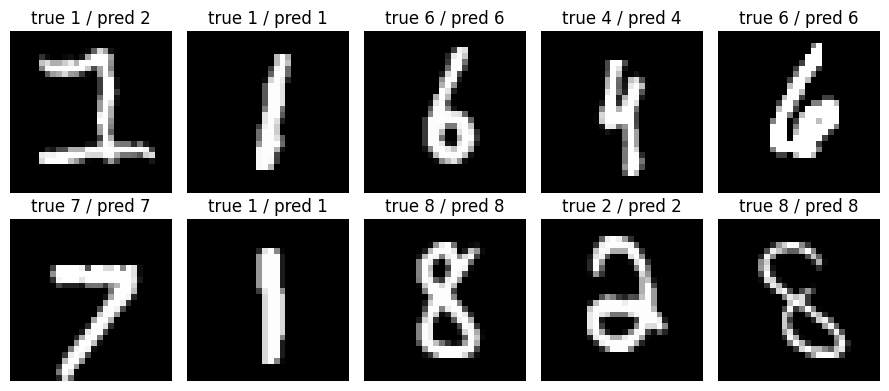

In [9]:
PREDICTION_COUNT = 10
resnet_sample_gray = test_images[:PREDICTION_COUNT]
resnet_sample_labels = test_labels[:PREDICTION_COUNT]

with torch.no_grad():
    sample_inputs = prepare_resnet_images(resnet_sample_gray).to(DEVICE)
    resnet_predictions = resnet18(sample_inputs).argmax(dim=1).cpu().numpy()

fig, axes = plt.subplots(2, 5, figsize=(9, 4))
for index, ax in enumerate(axes.ravel()):
    ax.imshow(resnet_sample_gray[index].squeeze().numpy(), cmap="gray")
    ax.set_title(f"true {resnet_sample_labels[index]} / pred {resnet_predictions[index]}")
    ax.axis("off")
plt.tight_layout()
plt.show()  # Display predictions from the trained classifier on test images.


### 6.3 CPU and GPU Inference Comparison

CNN inference contains many parallel convolution operations. A GPU can be faster than a CPU when the model and batch size are large enough. If no GPU is available, the code reports CPU only.

Because this ResNet uses ImageNet pretrained weights, the input batch is shaped as RGB images: `(batch_size, 3, height, width)`.


In [10]:
# Import timing utilities only for the CPU/GPU inference comparison.
import time


def synchronise(device: str) -> None:
    """Wait for asynchronous GPU work before reading the timer."""
    # GPU operations can run asynchronously. Synchronising makes the timing fairer.
    if device == "cuda":
        torch.cuda.synchronize()
    elif device == "mps" and hasattr(torch, "mps"):
        torch.mps.synchronize()


def time_inference(model: nn.Module, batch: torch.Tensor, device: str, repeats: int = 5) -> float:
    """Measure average inference time for a model and input batch."""
    model = model.to(device)
    batch = batch.to(device)
    model.eval()

    with torch.no_grad():
        # Warm-up runs reduce one-off setup effects in the timing result.
        for _ in range(3):
            _ = model(batch)
        synchronise(device)

        start = time.perf_counter()
        for _ in range(repeats):
            _ = model(batch)
        synchronise(device)
        end = time.perf_counter()

    return (end - start) / repeats


# Use RGB-shaped inputs because pretrained ResNet expects three-channel images.
# A smaller 64 x 64 size keeps this timing demo quick for a notebook.
TIMING_BATCH_SIZE = 16
TIMING_IMAGE_SIZE = 64
TIMING_REPEATS = 5  # Average several timed forward passes.
sample_batch = torch.randn(TIMING_BATCH_SIZE, 3, TIMING_IMAGE_SIZE, TIMING_IMAGE_SIZE)

# Always test CPU. Add GPU only if PyTorch can see one.
devices = ["cpu"]
if torch.cuda.is_available():
    devices.append("cuda")
elif torch.backends.mps.is_available():
    devices.append("mps")

# Time inference on each available device and collect results in a DataFrame.
timing_rows = []
for device in devices:
    seconds = time_inference(resnet18, sample_batch, device, repeats=TIMING_REPEATS)
    timing_rows.append({"device": device, "average_inference_seconds": seconds})

# Move the model back to the default device for later cells.
resnet18 = resnet18.to(DEVICE)
timing_df = pd.DataFrame(timing_rows)
timing_df


,device,average_inference_seconds
0,cpu,0.177168
1,mps,0.009437


## 7 - Image Style Transfer

Image style transfer combines the content of a photograph with the colours and texture patterns of a style reference, such as a painting.

![A fixed CNN extracts content and style representations. The combined loss supplies gradients that update the generated image pixels while the CNN weights remain fixed.](assets/session11-style-transfer.svg)

- **Content image $p$:** the frozen CNN extracts target features $P$ that describe the photograph's structures and their arrangement.
- **Style image $a$:** the same CNN extracts target Gram matrices $A$. These channel correlations describe texture patterns without retaining their exact positions.
- **Generated image $x$:** start from the content image or random noise. Pass it through the CNN to obtain current content features $F$ and style matrices $G$.
- **Combined loss:** compare $F$ with $P$ for content and $G$ with $A$ for style. Their relative weights control the balance between preserving structure and adopting the reference style.
- **Pixel updates:** backpropagate through the frozen CNN and repeatedly adjust only $x$. The CNN weights and reference targets stay fixed throughout the Gatys method.

[Gatys style transfer notebook](assets/style-transfer/gatys-style-transfer.ipynb)

[Download the notebook source](assets/style-transfer/gatys-style-transfer.ipynb){download="gatys-style-transfer.ipynb" data-noresolveinput="true"}
